In [1]:
#imported from Pranav Sanghavi's notebook 
import glob 
import os 
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.stats import iqr
import pytz,pickle,yaml,sys
from scipy.optimize import curve_fit
#importing for Will's extract_source_pulses function 
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable
#importing for drone and corr data synchronization
import pandas as pd
import datetime
import h5py
import os
import pygeodesy

#import the beamcals module, use forked repository (not original):
#sys.path.insert(0, '../../classes/')
#import corr, concat, drone
#import plotting_utils as pu
#import fitting_utils as fu
#import geometry_utils as gu
import time_utils as tu
#import site_utils as si
#gbosite=si.Site('../../metadata/TONE_d5_config.npz')
#gbosite=si.Site('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/TONE_d5_config.npz')


style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()
        
def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """
    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:
                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])
            else:
                yield consecutive_list
                consecutive_list = []        
        except Exception:
            pass   
    yield consecutive_list
    
def split_into_small_lists(big_lists, small_size=4, long_threshold=11, n_chunks=3, min_len=2):
    """
        This function splits the sublists of time indices of individual ON/OFF pulses into 3/4-element lists
        Returns list of lists
        - ≤11 elements: chunk into small_size
        - ≤2 elements: throw away the list 
    """
    small_chunks = []
    for list1 in big_lists:
        if len(list1) <= long_threshold:
            small_groups = [list1[i:i + small_size] for i in range(0, len(list1), small_size)]
        small_chunks.extend(small_groups)
    return [group for group in small_chunks if len(group) >= min_len]  # Drop empties if any


In [2]:
## 2.5m/s single pass 
## -- correlator data 
# reading the required only corr files for plotting beam pattern
file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*'

# reading files for main beam pass 
corr_data = read_corr_mode_h5(file_path, f_start=101, f_stop=104)
pow_mag, pow_phase = get_mag_phase(corr_data.vis)

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0101
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0101
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0102
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0102
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0103
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_ra

In [3]:
def drone_angles_for_corr_range_simple(dish_location, drone_file, corr_data_directory,
                                       start_file=0, stop_file=-1,
                                       use_ctime=False, output='degrees'):
    """
    Compute drone angles relative to a single dish location for a specific correlator file time range.
    Interpolates the drone positions to the correlator timestamps.

    Time handling matches the concat script: all times converted to float seconds since epoch.
    """

    # -----------------------
    # Step 1: Load correlator timestamps
    # -----------------------
    all_files = sorted([f for f in os.listdir(corr_data_directory) if ".lock" not in f])
    filenames = all_files[start_file:stop_file]
    if len(filenames) == 0:
        raise ValueError("No correlator files found in the specified range.")

    t_list = []
    for fname in filenames:
        with h5py.File(os.path.join(corr_data_directory, fname), 'r') as fd:
            if use_ctime:
                t_file = fd['index_map']['time']['ctime'][:].astype(float)
            else:
                t_file = 1e-9 * fd['index_map']['time']['irigb_time'][:].astype(float)
            t_list.append(t_file)
    t_corr = np.concatenate(t_list)

    # Convert correlator times to seconds since epoch
    t_corr_sec = t_corr if use_ctime else t_corr  # already in seconds
    # fallback: ensure numeric type
    t_corr_sec = np.array(t_corr_sec, dtype=float)

    # -----------------------
    # Step 2: Load drone CSV timestamps
    # -----------------------
    df = pd.read_csv(drone_file, low_memory=False)

    if 'datetime(utc)' in df.columns and 'time(millisecond)' in df.columns:
        t0 = pd.to_datetime(df['datetime(utc)'], utc=True).iloc[0]
        drone_times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                                for x in df['time(millisecond)']])
    elif 'GPS:dateTimeStamp' in df.columns:
        drone_times = pd.to_datetime(df['GPS:dateTimeStamp'], utc=True).map(lambda t: t.timestamp()).values
    else:
        raise KeyError("No recognizable time columns in drone file.")

    # -----------------------
    # Step 3: Mask drone data to correlator time range
    # -----------------------
    t_start_sec, t_stop_sec = t_corr_sec[0], t_corr_sec[-1]
    mask = (drone_times >= t_start_sec) & (drone_times <= t_stop_sec)
    if not mask.any():
        raise ValueError("No drone data falls within the correlator time range.")
    df_masked = df.loc[mask].copy()
    drone_times = drone_times[mask]

    # -----------------------
    # Step 4: Extract drone positions
    # -----------------------
    if 'RTKdata:Lat_P' in df_masked.columns:
        lat = df_masked['RTKdata:Lat_P'].values
        lon = df_masked['RTKdata:Lon_P'].values
        alt = df_masked['RTKdata:Hmsl_P'].values
    elif 'GPS(0):Lat' in df_masked.columns:
        lat = df_masked['GPS(0):Lat'].values
        lon = df_masked['GPS(0):Long'].values
        alt = df_masked['GPS(0):heightMSL'].values
    elif 'GPS:Lat' in df_masked.columns:
        lat = df_masked['GPS:Lat'].values
        lon = df_masked['GPS:Long'].values
        alt = df_masked['GPS:heightMSL'].values
    elif 'latitude' in df_masked.columns:
        lat = df_masked['latitude'].values
        lon = df_masked['longitude'].values
        if 'altitude(meters)' in df_masked.columns:
            alt = df_masked['altitude(meters)'].values
        elif 'altitude(feet)' in df_masked.columns:
            alt = df_masked['altitude(feet)'].values * 0.3048
        else:
            raise KeyError("No altitude column found in drone file.")
    else:
        raise KeyError("No recognizable latitude/longitude columns in drone file.")

    # Remove NaNs
    valid_mask = ~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(alt)
    lat, lon, alt = lat[valid_mask], lon[valid_mask], alt[valid_mask]
    drone_times = drone_times[valid_mask]

    # -----------------------
    # Step 5: Convert drone positions to local Cartesian coordinates
    # -----------------------
    origin_lat, origin_lon, origin_alt = dish_location
    prime_origin = pygeodesy.EcefCartesian(latlonh0=origin_lat, lon0=origin_lon, height0=origin_alt)

    drone_xyz = np.zeros((len(lat), 3))
    for i in range(len(lat)):
        p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
        drone_xyz[i] = prime_origin.forward(p).toVector()

    # -----------------------
    # Step 6: Compute angles relative to dish
    # -----------------------
    drone_xyz_rel = drone_xyz  # dish at origin
    #horizontal_dist = np.linalg.norm(drone_xyz_rel[:, :2], axis=1)
    horizontal_dist = np.abs(drone_xyz_rel[:, 1])
    vertical_dist = np.abs(drone_xyz_rel[:, 2])
    drone_angles = np.arctan2(horizontal_dist, vertical_dist)

    # -----------------------
    # Step 7: Interpolate angles to correlator timestamps
    # -----------------------
    angles_interp = np.interp(t_corr_sec, drone_times, drone_angles)

    if output.lower() == 'degrees':
        angles_interp = np.degrees(angles_interp)

    return angles_interp


Total drone positions recorded: 768


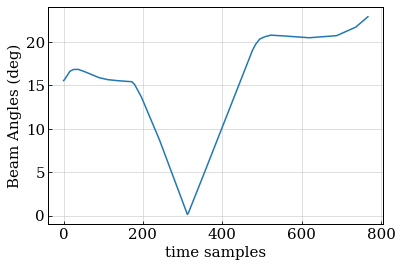

In [4]:
drone_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_processed/YaleApr2025_drone_files/Apr-12th-2025-03-58PM-Flight-Airdata.csv"
corr_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z"
dish_loc = [41.31899934, -72.92132019, 25] 

# Compute angles using the simplified function
drone_angles = drone_angles_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=101,
    stop_file=104,
    use_ctime=True,
    output='degrees'
)

# Preview first few angles
plt.plot(drone_angles)
#plt.ylim(20,25)
#plt.xlim(400,800)
plt.xlabel("time samples")
plt.ylabel("Beam Angles (deg)")
print(f"Total drone positions recorded: {len(drone_angles)}")

zero_idx = np.where(drone_angles == np.min(drone_angles))[0][0]
drone_angles[:zero_idx] = -drone_angles[:zero_idx]

In [5]:

"""
    WTyndall's function imported for fitting ON and OFF pulse points 
"""

def Extract_Source_Pulses_pub(self,f_ind):
    #If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        #Create Switch Signal:
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        #Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)# 1ms steps 
        #n_channels = 10 # for GBO
        n_channels = 3 # for Yale 
        #channel_indices = [0,1,2,3,4,5,6,7,8,9] # for GBO
        channel_indices = [7,8,9] # for Yale 
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        #Given parameters:
        num_bins = len(pow_mag[:,f_ind,9]) # 9 for yale; 9 in N2 matrix is ref channel
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_full = np.arange(num_bins) * time_bin_width

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i, ch_index in enumerate(channel_indices):
            ## Finding a baseline power level that’s almost the minimum, subtract it from the signal 
            ## so that ‘background’ power becomes zero before normalization.”
            minsubdata=self.vis[:,f_ind,ch_index]-np.percentile(self.vis[:,f_ind,ch_index],minmaxpercents[0])
            ## make all channels have the same range (0–1), so the Pearson correlation step later isn’t skewed by power differences.
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            ## clipping ensures baseline stays at 0 and maximum stays at 1 
            ## makes it directly comparable to our ideal square wave (0 = OFF, 1 = ON) 
            ## so Pearson correlation can find the best alignment.
            clipnormminsubdata=normminsubdata.clip(0,1)
            ## turns your cleaned signal into a function you can call at any time point,
            ## holding each sample’s value until the next one, so you can match it directly 
            ## to the ideal pulse pattern.
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)

            ##Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'*',label=str(i))
           
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
                
        # Always considering reference channel for fitting (time offset from ref) as anyways switching is in sync 
        # Always point this index to the ref channel 
        #self.t_delta_pulse=Pr_max_t_0_per_channel[9]  # for GBO
        self.t_delta_pulse=Pr_max_t_0_per_channel[2]  # for Yale 
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))

        
        
        t_arr_datetime = t_full 
        #Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        #Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
 
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

        #Making subsets of on and off indices for individual ON/OFFs: 
        indon_list=list(chunk_lists_(self.inds_on))
        indoff_list=list(chunk_lists_(self.inds_off))
        #Calculating stats for individual ON/OFF pulses:
        #channel_indices = [0,1,2,3,4,5,6,7,8,9] # for GBO
        channel_indices = [7,8,9] #for Yale 
        
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        for i,channel_index in enumerate(channel_indices):
            print("Frequency bin: "+str(f_ind))
            all_data = pow_mag[:,f_ind,channel_index]
            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],pow_mag[:,f_ind,channel_index],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        #corr33_dat= pow_mag[:,f_ind,3] # for GBO
        corr99_dat= pow_mag[:,f_ind,9] # for Yale 
        #ax_align.plot(t_arr_datetime, corr33_dat, label='Actual Data') # for GBO
        ax_align.plot(t_arr_datetime, corr99_dat, label='Actual Data')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        return self.inds_on, self.inds_off, self.inds_span

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [750. 893. 750.]
  --> t_deltas = [-0.25  -0.107 -0.25 ]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.2498000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []
Frequency bin: 325
Frequency bin: 325
Frequency bin: 325


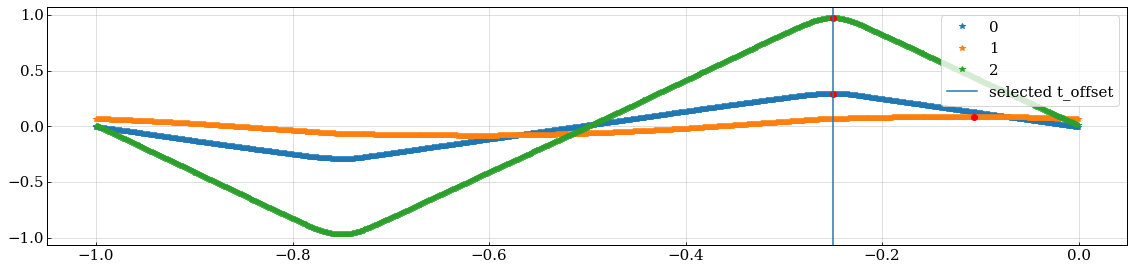

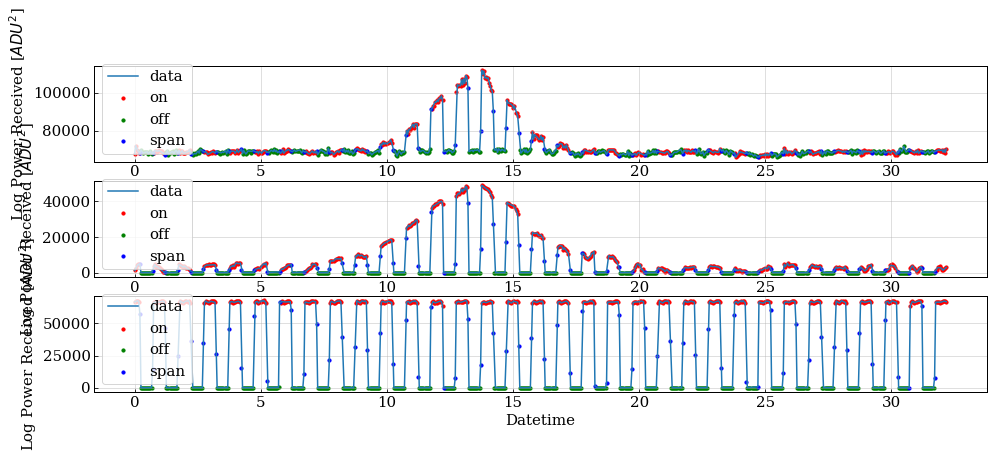

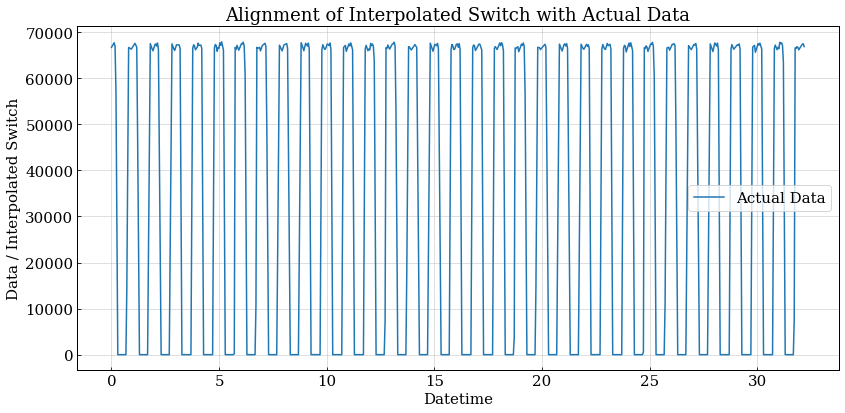

768

In [6]:
inds_on, inds_off, inds_span=Extract_Source_Pulses_pub(corr_data, f_ind=325)
len(inds_on)+len(inds_off)+len(inds_span)

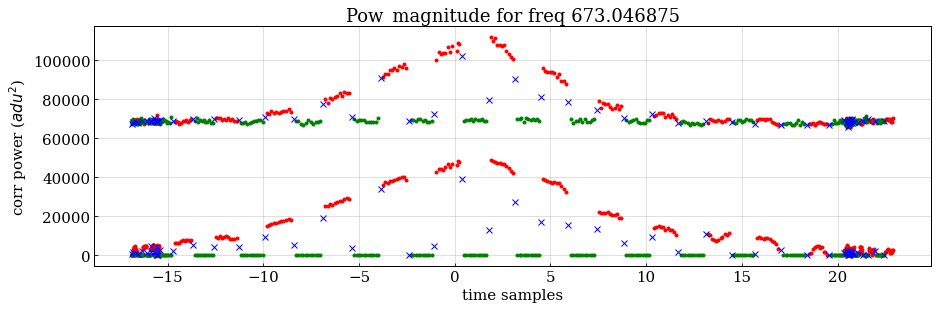

In [8]:
## overlaying autos and crosses from drone beam pass -- 

corr_size=corr_data.vis[:,:,:].shape 
tmin,tmax=[0,corr_size[0]]
freq_arr=[325]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[15,15])
    freq=400+((1024-f_ind)*0.390625)
    ax=plt.subplot(dim2, dim1, index+1)
    ax.plot(drone_angles[inds_on],pow_mag[inds_on,f_ind,7],'.', c='red', label='auto on data')
    ax.plot(drone_angles[inds_off],pow_mag[inds_off,f_ind,7],'.', c='green', label='auto off data')
    ax.plot(drone_angles[inds_span],pow_mag[inds_span,f_ind,7],'x', c='blue', label='auto rising/falling edge data')
    
    ax.plot(drone_angles[inds_on],pow_mag[inds_on,f_ind,8],'.', c='red', label='cross on data')
    ax.plot(drone_angles[inds_off],pow_mag[inds_off,f_ind,8],'.', c='green', label='cross off data')
    ax.plot(drone_angles[inds_span],pow_mag[inds_span,f_ind,8],'x', c='blue', label='cross rising/falling edge data')
    
    plt.title(f"Pow_magnitude for freq {freq}")
    plt.xlabel("time samples")
    plt.ylabel("corr power ($adu^2$)")